# PY-06 — Análise Exploratória de Dados (EDA)

**Projeto:** análise de dados de vendas com Pandas, Matplotlib e Seaborn  
**Ambiente:** Google Colab  
**Arquivo necessário:** `sales_data.csv`

## Objetivos

Ao final, você será capaz de:

1. carregar um arquivo CSV no Colab;
2. inspecionar estrutura, tipos e qualidade dos dados;
3. criar variáveis úteis para a análise;
4. produzir e interpretar visualizações;
5. comunicar conclusões e recomendações;
6. publicar o notebook e o CSV em um repositório do GitHub.

> Execute as células na ordem. Use **Shift + Enter** para executar uma célula.

## 1. Preparação do ambiente

O Colab já possui as principais bibliotecas. Vamos importá-las e definir um estilo visual.

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Ambiente preparado.")

Ambiente preparado.


## 2. Conectar ao arquivo CSV

Ao executar a célula, clique em **Escolher arquivos** e selecione `sales_data.csv`.
O arquivo é enviado apenas para a sessão atual do Colab; se a sessão for reiniciada, será necessário enviá-lo novamente.

In [2]:
# from google.colab import files

# arquivos_enviados = files.upload()
nome_arquivo = 'sales_data.csv'
dados = pd.read_csv(nome_arquivo)

colunas_necessarias = {"Sales", "Region", "Product", "Date", "Cost"}
colunas_ausentes = colunas_necessarias - set(dados.columns)

if colunas_ausentes:
    raise ValueError(f"O CSV não contém as colunas: {sorted(colunas_ausentes)}")

print(f"Arquivo carregado: {nome_arquivo}")
print(f"Dimensões: {dados.shape[0]} linhas × {dados.shape[1]} colunas")
display(dados.head())

Arquivo carregado: sales_data.csv
Dimensões: 10 linhas × 5 colunas


,Sales,Region,Product,Date,Cost
0,250,North,A,2024-01-01,216.31
1,400,East,B,2024-01-02,348.15
2,150,West,C,2024-01-03,123.00
3,350,South,D,2024-01-04,296.90
4,500,North,A,2024-01-05,378.85


## 3. Inspeção inicial — conhecer antes de transformar

Perguntas orientadoras:

- Quantas linhas e colunas existem?
- O que cada linha representa?
- Quais tipos foram identificados?
- Há valores ausentes ou duplicados?
- Os valores numéricos parecem plausíveis?

In [3]:
print("Dimensões:", dados.shape)
display(dados.head())
display(dados.sample(min(5, len(dados)), random_state=42))

print("\nInformações do DataFrame:")
dados.info()

Dimensões: (10, 5)


,Sales,Region,Product,Date,Cost
0,250,North,A,2024-01-01,216.31
1,400,East,B,2024-01-02,348.15
2,150,West,C,2024-01-03,123.00
3,350,South,D,2024-01-04,296.90
4,500,North,A,2024-01-05,378.85


,Sales,Region,Product,Date,Cost
8,600,North,A,2024-01-09,411.56
1,400,East,B,2024-01-02,348.15
5,300,East,B,2024-01-06,218.94
0,250,North,A,2024-01-01,216.31
7,450,South,D,2024-01-08,363.14



Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sales    10 non-null     int64  
 1   Region   10 non-null     str    
 2   Product  10 non-null     str    
 3   Date     10 non-null     str    
 4   Cost     10 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 532.0 bytes


In [4]:
print("Valores ausentes por coluna:")
display(dados.isna().sum().to_frame("quantidade"))

print("Linhas duplicadas:", dados.duplicated().sum())

print("\nResumo estatístico:")
display(dados.describe(include="all").T)

Valores ausentes por coluna:


,quantidade
Sales,0
Region,0
Product,0
Date,0
Cost,0


Linhas duplicadas: 0

Resumo estatístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sales,10.0,NaN,NaN,NaN,325.0,168.737139,50.0,212.5,325.0,437.5,600.0
Region,10,4,North,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,10,4,A,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,10,10,2024-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost,10.0,NaN,NaN,NaN,256.776,122.868683,38.46,183.415,257.92,359.3925,411.56


### Leitura do resumo

- **mean**: média;
- **50%**: mediana;
- **std**: dispersão em torno da média;
- **min/max**: extremos observados;
- **count**: quantidade de valores não nulos.

Valores extremos não são automaticamente erros ou *outliers*. Eles são sinais que precisam de investigação.

## 4. Ajuste dos tipos de dados

A coluna `Date` foi carregada como texto. Convertê-la para data permite ordenar, agrupar e criar novas informações temporais.

In [5]:
dados["Date"] = pd.to_datetime(dados["Date"], errors="coerce")
dados["Region"] = dados["Region"].astype("string")
dados["Product"] = dados["Product"].astype("string")

if dados["Date"].isna().any():
    print("Atenção: algumas datas não puderam ser convertidas.")

dados = dados.sort_values("Date").reset_index(drop=True)
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Sales    10 non-null     int64         
 1   Region   10 non-null     string        
 2   Product  10 non-null     string        
 3   Date     10 non-null     datetime64[us]
 4   Cost     10 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1), string(2)
memory usage: 532.0 bytes


## 5. Engenharia de atributos

Criar atributos significa transformar dados existentes em informações mais úteis para responder perguntas.

- `Month`: mês da venda;
- `Day_of_Week`: dia da semana;
- `Profit`: venda menos custo;
- `Margin_Percent`: lucro em relação à venda;
- `Sales_Normalized`: vendas na escala de 0 a 1;
- `Sales_Tier`: classificação de valor da venda.

In [6]:
dias_pt = {
    "Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta",
    "Thursday": "Quinta", "Friday": "Sexta", "Saturday": "Sábado",
    "Sunday": "Domingo"
}

dados["Month"] = dados["Date"].dt.month
dados["Day_of_Week"] = dados["Date"].dt.day_name().map(dias_pt)
dados["Profit"] = dados["Sales"] - dados["Cost"]
dados["Margin_Percent"] = np.where(
    dados["Sales"] != 0, dados["Profit"] / dados["Sales"] * 100, np.nan
)

amplitude = dados["Sales"].max() - dados["Sales"].min()
dados["Sales_Normalized"] = (
    (dados["Sales"] - dados["Sales"].min()) / amplitude
    if amplitude != 0 else 0
)
dados["Sales_Tier"] = np.where(dados["Sales"] > 300, "Alta", "Baixa")

display(dados.head())

,Sales,Region,Product,Date,Cost,Month,Day_of_Week,Profit,Margin_Percent,Sales_Normalized,Sales_Tier
0,250,North,A,2024-01-01,216.31,1,Segunda,33.69,13.476000,0.363636,Baixa
1,400,East,B,2024-01-02,348.15,1,Terça,51.85,12.962500,0.636364,Alta
2,150,West,C,2024-01-03,123.00,1,Quarta,27.00,18.000000,0.181818,Baixa
3,350,South,D,2024-01-04,296.90,1,Quinta,53.10,15.171429,0.545455,Alta
4,500,North,A,2024-01-05,378.85,1,Sexta,121.15,24.230000,0.818182,Alta


## 6. Análise não visual

Agrupar dados ajuda a responder perguntas de negócio. Não basta apresentar um número: explique o que ele significa e qual decisão ele pode apoiar.

In [7]:
resumo_regiao = (
    dados.groupby("Region", as_index=False)
         .agg(Vendas=("Sales", "sum"),
              Custos=("Cost", "sum"),
              Lucro=("Profit", "sum"),
              Transacoes=("Sales", "count"))
         .sort_values("Vendas", ascending=False)
)
display(resumo_regiao)

,Region,Vendas,Custos,Lucro,Transacoes
1,North,1350,1006.72,343.28,3
2,South,800,660.04,139.96,2
0,East,750,605.55,144.45,3
3,West,350,295.45,54.55,2


In [8]:
ordem_dias = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

vendas_por_dia = (
    dados.groupby("Day_of_Week")["Sales"]
         .sum()
         .reindex(ordem_dias, fill_value=0)
)

print("Vendas totais por dia:")
display(vendas_por_dia.to_frame("Sales"))
print("Maior total:", vendas_por_dia.max())
print("Dia(s) com maior total:", ", ".join(vendas_por_dia[vendas_por_dia == vendas_por_dia.max()].index))
print("Menor total:", vendas_por_dia.min())
print("Dia(s) com menor total:", ", ".join(vendas_por_dia[vendas_por_dia == vendas_por_dia.min()].index))

Vendas totais por dia:


,Sales
Day_of_Week,
Segunda,700
Terça,1000
Quarta,200
Quinta,350
Sexta,500
Sábado,300
Domingo,200


Maior total: 1000
Dia(s) com maior total: Terça
Menor total: 200
Dia(s) com menor total: Quarta, Domingo


## 7. Análise visual

Antes de criar um gráfico, formule uma pergunta. Depois, escolha o gráfico e interprete o padrão observado.

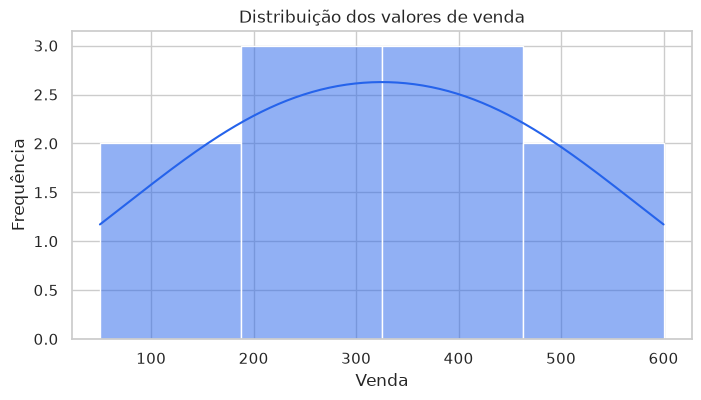

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(data=dados, x="Sales", bins=4, kde=True, color="#2563eb")
plt.title("Distribuição dos valores de venda")
plt.xlabel("Venda")
plt.ylabel("Frequência")
plt.show()

**Discussão:** existem poucos registros, portanto muitos intervalos podem fragmentar demais o histograma. Observe valores baixos e altos, mas não os classifique automaticamente como erros.

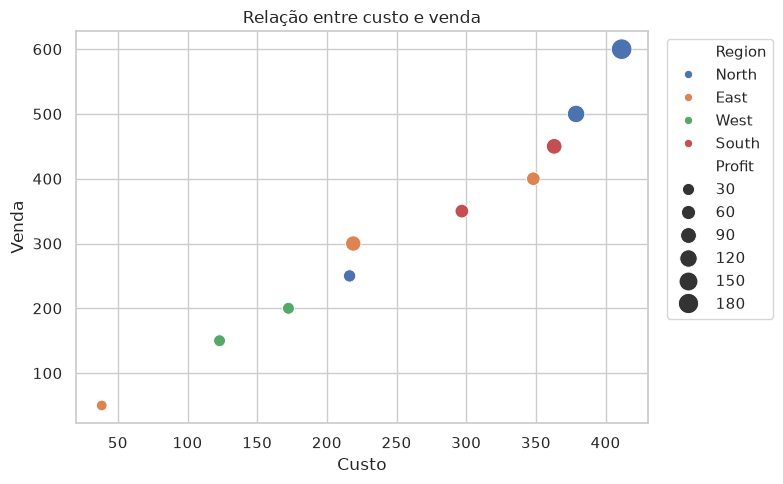

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dados, x="Cost", y="Sales",
    hue="Region", size="Profit", sizes=(60, 220)
)
plt.title("Relação entre custo e venda")
plt.xlabel("Custo")
plt.ylabel("Venda")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

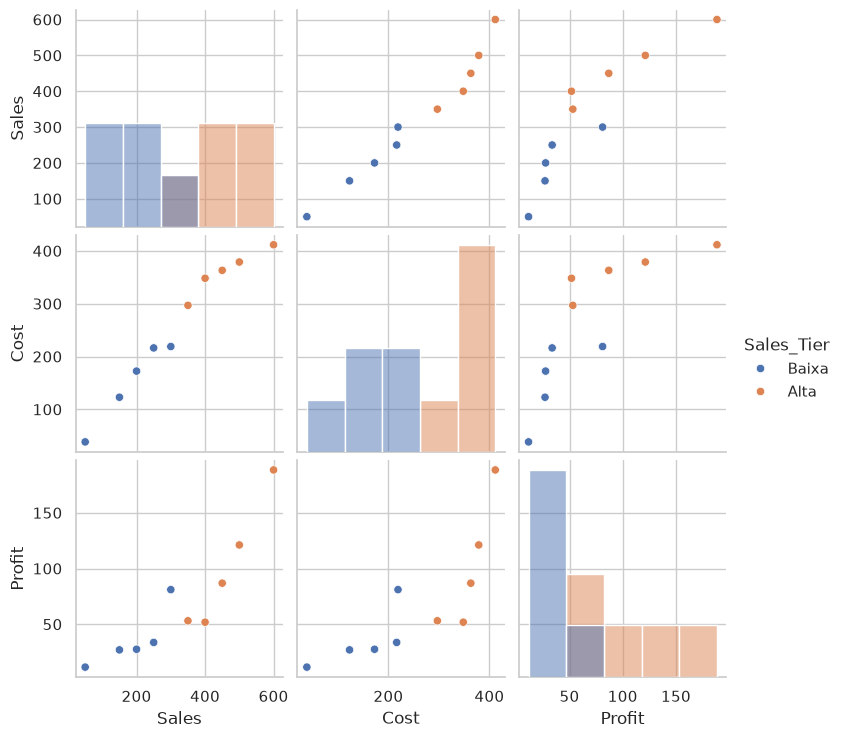

In [11]:
sns.pairplot(
    dados[["Sales", "Cost", "Profit", "Sales_Tier"]],
    hue="Sales_Tier",
    diag_kind="hist"
)
plt.show()

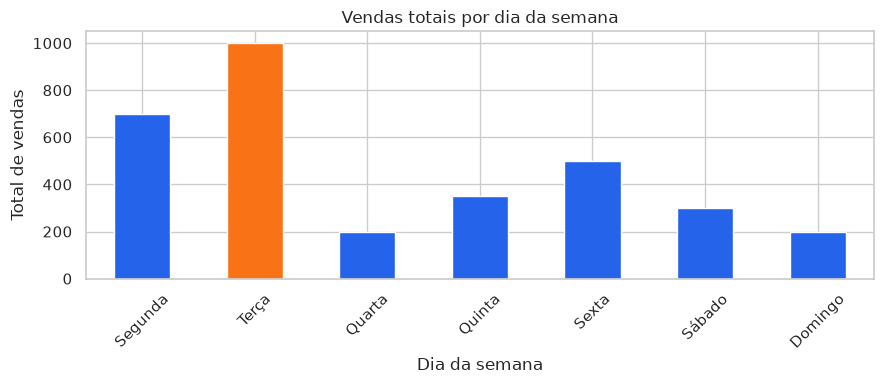

In [12]:
plt.figure(figsize=(9, 4))
cores = ["#2563eb" if valor < vendas_por_dia.max() else "#f97316"
         for valor in vendas_por_dia.values]
vendas_por_dia.plot(kind="bar", color=cores)
plt.title("Vendas totais por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Total de vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Atividade em dupla — relatório de EDA

**Tempo sugerido: 15 minutos**

## Entrega

A dupla deverá manter no notebook:

1. a célula de conexão ao `sales_data.csv`;
2. uma análise não visual das vendas por dia;
3. um gráfico de barras das vendas por dia;
4. uma interpretação escrita;
5. duas recomendações práticas;
6. o notebook e o CSV publicados no GitHub.

## Papéis sugeridos

- **Pessoa A:** executa e explica o código;
- **Pessoa B:** verifica os resultados e registra as interpretações;
- troquem os papéis no momento do gráfico.

## 8. Código da dupla — análise não visual

Complete os espaços indicados. Evite apagar as análises anteriores.

In [14]:
# TODO 1: agrupe Sales por Day_of_Week e use a ordem definida em ordem_dias
relatorio_semanal = (
    dados.groupby("Day_of_Week")["Sales"]
         .sum()
         .reindex(ordem_dias, fill_value=0)
)

display(relatorio_semanal)

Day_of_Week
Segunda     700
Terça      1000
Quarta      200
Quinta      350
Sexta       500
Sábado      300
Domingo     200
Name: Sales, dtype: int64

In [15]:
# TODO 2: identifique todos os dias empatados no maior e no menor total
maior_total = relatorio_semanal.max()
menor_total = relatorio_semanal.min()

dias_fortes = relatorio_semanal[relatorio_semanal == maior_total].index.tolist()
dias_fracos = relatorio_semanal[relatorio_semanal == menor_total].index.tolist()

print("Dia(s) forte(s):", dias_fortes, "| Total:", maior_total)
print("Dia(s) fraco(s):", dias_fracos, "| Total:", menor_total)

Dia(s) forte(s): ['Terça'] | Total: 1000
Dia(s) fraco(s): ['Quarta', 'Domingo'] | Total: 200


## 9. Código da dupla — visualização

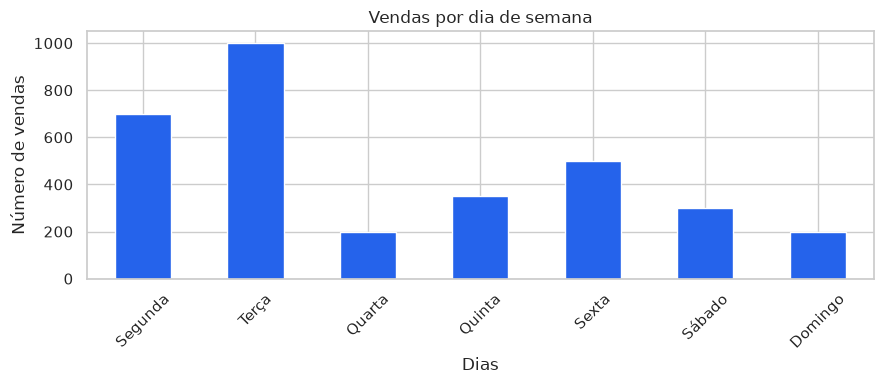

In [19]:
# TODO 3: crie um gráfico de barras para relatorio_semanal
plt.figure(figsize=(9, 4))
relatorio_semanal.plot(kind="bar", color="#2563eb")
plt.title("Vendas por dia de semana")
plt.xlabel("Dias")
plt.ylabel("Número de vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Interpretação e recomendações da dupla

Substituam o texto:

**Principal padrão observado:**  
Possível notar que as vendas são altas no início da semana (segunda e terça), porém têm uma queda considerável nos dias decorrentes.

**Cuidado com a conclusão:**  
A análise leva em conta apenas 10 dias no mês, portanto é uma amostra bem pequena do que pode acontecer. Algumas conclusões podem não se aplicar com mais amostras de dados.

**Recomendação 1 — aproveitar dias fortes:**  
Manter o que vêm sendo feito.

**Recomendação 2 — desenvolver dias fracos:**  
Criar promoções, principalmente nos fins de semanas onde o público está mais disponível a ir às compras.

## 11. Exportar o conjunto analisado

Esta etapa cria um novo CSV com os atributos que adicionamos.

In [18]:
nome_saida = "sales_data_analisado.csv"
dados.to_csv(nome_saida, index=False)
print(f"Arquivo criado: {nome_saida}")

# from google.colab import files
# files.download(nome_saida)

Arquivo criado: sales_data_analisado.csv


# Publicar no GitHub

## Parte A — baixar o notebook do Colab

1. Confirme que as células foram executadas e que a interpretação foi preenchida.
2. No menu do Colab, clique em **Arquivo → Fazer download → Fazer download do .ipynb**.
3. Guarde o arquivo com um nome claro, como `PY-06_EDA_Vendas_NomesDaDupla.ipynb`.

## Parte B — criar o repositório

1. Entre no GitHub.
2. Clique no **+** no canto superior direito e escolha **New repository**.
3. Nome sugerido: `analise-exploratoria-vendas`.
4. Adicione uma descrição curta.
5. Escolha **Public** ou **Private**, conforme a orientação docente.
6. Marque **Add a README file**.
7. Clique em **Create repository**.

## Parte C — enviar os arquivos

1. Dentro do repositório, clique em **Add file → Upload files**.
2. Envie:
   - o notebook `.ipynb`;
   - `sales_data.csv`;
   - opcionalmente `sales_data_analisado.csv`.
3. Escreva uma mensagem, por exemplo: `Adiciona análise exploratória de vendas`.
4. Confirme o commit.
5. Abra o notebook dentro do repositório e verifique se ele aparece corretamente.

## Parte D — completar o README

Inclua:

- objetivo do projeto;
- origem e nome do conjunto de dados;
- bibliotecas usadas;
- etapas da análise;
- principais conclusões;
- instruções para executar o notebook no Colab.

> Nunca publique senhas, tokens ou chaves de acesso. O CSV desta atividade não contém credenciais.